In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from pm.utils.data import DataManager

from utils.components import (
    MacroDataDownloader,
    MacroTransformCalculator,
    MacroCorrelationCalculator,
    MacroRegressionCalculator,
    FactorCollinearityAnalyzer
)

from utils.analyzers import (
    MacroFactorAnalyzer,
    MacroCorrelationAnalyzer,
    MacroSensitivityAnalyzer,
    MacroSituationAnalyzer,
    FactorSelectionAnalyzer
)

from utils.reporters import (
    MacroFactorReporter,
    MacroCorrelationReporter,
    MacroSensitivityReporter,
    MacroSituationReporter
)

from utils.visualizations import (
    MacroFactorVisualizer,
    MacroCorrelationVisualizer,
    MacroSensitivityVisualizer,
    MacroSituationVisualizer
)

from utils.tools import (
    MACRO_GLOBAL_FACTORS,
    FACTORS_TO_USE,
    ANNUAL_FACTOR,   
    REGIME_WINDOW     
)

In [3]:
# ═══════════════════════════════════════════════════════════════════
# COMPONENTES DE BAJO NIVEL (Cálculos específicos)
# ═══════════════════════════════════════════════════════════════════

# Descargador de datos macro
data_downloader = MacroDataDownloader()

# Transformador de factores
transform_calc = MacroTransformCalculator()

# Calculadores específicos
correlation_calc = MacroCorrelationCalculator(max_lag=126)
regression_calc = MacroRegressionCalculator(annual_factor=ANNUAL_FACTOR, use_hac=True)
collinearity_calc = FactorCollinearityAnalyzer(corr_threshold=0.9, vif_threshold=10.0)

# ═══════════════════════════════════════════════════════════════════
# ANALYZERS DE ALTO NIVEL (Orquestación + Insights)
# ═══════════════════════════════════════════════════════════════════

factor_analyzer = MacroFactorAnalyzer(annual_factor=ANNUAL_FACTOR)
corr_analyzer = MacroCorrelationAnalyzer(max_lag=126)
sens_analyzer = MacroSensitivityAnalyzer(annual_factor=ANNUAL_FACTOR)
situation_analyzer = MacroSituationAnalyzer()
selector = FactorSelectionAnalyzer(
    corr_threshold=0.9, 
    vif_threshold=10.0, 
    force_keep=FACTORS_TO_USE
)

# ═══════════════════════════════════════════════════════════════════
# REPORTERS Y VISUALIZERS
# ═══════════════════════════════════════════════════════════════════

factor_reporter = MacroFactorReporter(factor_analyzer)
corr_reporter = MacroCorrelationReporter(corr_analyzer)
sens_reporter = MacroSensitivityReporter(sens_analyzer)
situation_reporter = MacroSituationReporter(situation_analyzer)

factor_viz = MacroFactorVisualizer(factor_analyzer)
corr_viz = MacroCorrelationVisualizer(corr_analyzer)
sens_viz = MacroSensitivityVisualizer(sens_analyzer)
situation_viz = MacroSituationVisualizer(situation_analyzer)

In [4]:
# Configuración del portfolio a analizar
TICKERS = ["BTC-EUR", "IONQ", "META"]
WEIGHTS = np.ones(len(TICKERS)) / len(TICKERS)
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

print(f"📈 Portfolio: {', '.join(TICKERS)}")
print(f"⚖️  Pesos: Equal-weighted ({WEIGHTS[0]:.2%} cada uno)")
print(f"📅 Período: {START_DATE} → {END_DATE}")

📈 Portfolio: BTC-EUR, IONQ, META
⚖️  Pesos: Equal-weighted (33.33% cada uno)
📅 Período: 2020-01-01 → 2024-12-31


In [5]:
# Descargar datos del portfolio
data_manager = DataManager()
assets_prices, _ = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name="SP500",
    start_date=START_DATE,
    end_date=END_DATE
)

# Calcular retornos del portfolio
returns = assets_prices.pct_change().dropna()
portfolio_returns = (returns * WEIGHTS).sum(axis=1)

print(f"\n✅ Portfolio returns: {len(portfolio_returns)} observaciones")
print(f"   Rango: {portfolio_returns.index[0].date()} → {portfolio_returns.index[-1].date()}")
print(f"   Retorno promedio diario: {portfolio_returns.mean():.4%}")
print(f"   Volatilidad diaria: {portfolio_returns.std():.4%}")

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  3 of 3 completed


Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  1 of 1 completed

Portafolio descargado: 3 activos + benchmark

✅ Portfolio returns: 1003 observaciones
   Rango: 2021-01-05 → 2024-12-30
   Retorno promedio diario: 0.2078%
   Volatilidad diaria: 3.0011%


In [6]:
# ═══════════════════════════════════════════════════════════════════
# PASO 1: DESCARGA DE FACTORES MACRO
# ═══════════════════════════════════════════════════════════════════

print("📥 Descargando factores macro...")
factors_raw = data_downloader.download_factors(
    factor_names=MACRO_GLOBAL_FACTORS, 
    start_date=START_DATE,
    end_date=END_DATE,
    progress=True
)
print(f"✅ Descargados {len(factors_raw)} factores")

# ═══════════════════════════════════════════════════════════════════
# PASO 2: TRANSFORMACIÓN DE FACTORES
# ═══════════════════════════════════════════════════════════════════

print("\n🔄 Transformando factores (log returns, diffs, scaling)...")
factors_dict, factors_df = transform_calc.transform_all_factors(
    factors_raw,
    target_index=portfolio_returns.index,
    fill_method='ffill'
)
print(f"✅ {factors_df.shape[1]} factores transformados")

# ═══════════════════════════════════════════════════════════════════
# PASO 3: CÁLCULO DE SPREADS
# ═══════════════════════════════════════════════════════════════════

print("\n📐 Calculando spreads...")
spreads_df = transform_calc.calculate_all_spreads(factors_df)

if not spreads_df.empty:
    print(f"✅ {spreads_df.shape[1]} spreads calculados:")
    for spread in spreads_df.columns:
        print(f"   • {spread}")
    factors_complete = pd.concat([factors_df, spreads_df], axis=1)
else:
    print("⚠️  No hay spreads calculados")
    factors_complete = factors_df.copy()

# ═══════════════════════════════════════════════════════════════════
# PASO 4: ALINEACIÓN CON PORTFOLIO
# ═══════════════════════════════════════════════════════════════════

print("\n🎯 Alineando factores con portfolio...")
factors_aligned = transform_calc.align_to_portfolio(
    factors_complete, 
    portfolio_returns
)

# Seleccionar factores específicos + spreads
factors_to_analyze = FACTORS_TO_USE + list(spreads_df.columns)
factors_for_analysis = factors_aligned[factors_to_analyze].dropna()

print(f"✅ Factores listos para análisis:")
print(f"   • Factores: {factors_for_analysis.shape[1]}")
print(f"   • Observaciones: {factors_for_analysis.shape[0]}")
print(f"   • Período: {factors_for_analysis.index[0].date()} → {factors_for_analysis.index[-1].date()}")

📥 Descargando factores macro...


[*********************100%***********************]  20 of 20 completed


✅ Descargados 20 factores

🔄 Transformando factores (log returns, diffs, scaling)...
[Macro] OIL: 1 valores <= 0, reemplazados por NaN
✅ 20 factores transformados

📐 Calculando spreads...
✅ 3 spreads calculados:
   • yield_curve_30_10y
   • credit_spread_hy
   • credit_spread_hy_lqd

🎯 Alineando factores con portfolio...
✅ Factores listos para análisis:
   • Factores: 14
   • Observaciones: 1003
   • Período: 2021-01-05 → 2024-12-30


In [7]:
# ═══════════════════════════════════════════════════════════════════
# LIMPIEZA DE COLINEALIDAD
# ═══════════════════════════════════════════════════════════════════

print("🔍 Analizando colinealidad entre factores...")
sel_res = selector.analyze(factors_for_analysis)
pruned_factors = sel_res["pruned_factors"]

print(f"\n📊 Resultados de limpieza:")
print(f"   • Factores originales: {factors_for_analysis.shape[1]}")
print(f"   • Factores después de limpieza: {pruned_factors.shape[1]}")
print(f"   • Factores eliminados: {factors_for_analysis.shape[1] - pruned_factors.shape[1]}")

if factors_for_analysis.shape[1] - pruned_factors.shape[1] > 0:
    removed = set(factors_for_analysis.columns) - set(pruned_factors.columns)
    print(f"   • Removidos por colinealidad: {', '.join(removed)}")

🔍 Analizando colinealidad entre factores...

📊 Resultados de limpieza:
   • Factores originales: 14
   • Factores después de limpieza: 11
   • Factores eliminados: 3
   • Removidos por colinealidad: yield_curve_30_10y, credit_spread_hy_lqd, credit_spread_hy


📊 Ejecutando regresión multifactor...
                      ANÁLISIS DE FACTORES MACRO                      
RESUMEN DE REGRESIÓN
  Alpha (diario):             0.1314%
  Alpha (anual):               39.22%
  R²:                          0.399
  R² ajustado:                 0.392
  Observaciones:                1003
  Interpretación:           Excelente - genera alpha significativo
FACTOR LOADINGS (BETAS)
Factor                     Beta     t-stat    p-value Signif    
SP500                    1.6128     10.183     0.0000 ***       
HYG                      0.4055      1.489     0.1366           
GOVT_20Y                -0.3493     -1.349     0.1772           
DXY                      0.3482      1.442     0.1493           
RATE_2Y                 -0.2453     -1.170     0.2421           
RATE_10Y                -0.2199     -0.402     0.6880           
LQD                      0.2178      0.463     0.6434           
RATE_30Y                -0.1690     -0.320     0.7491           
OIL    

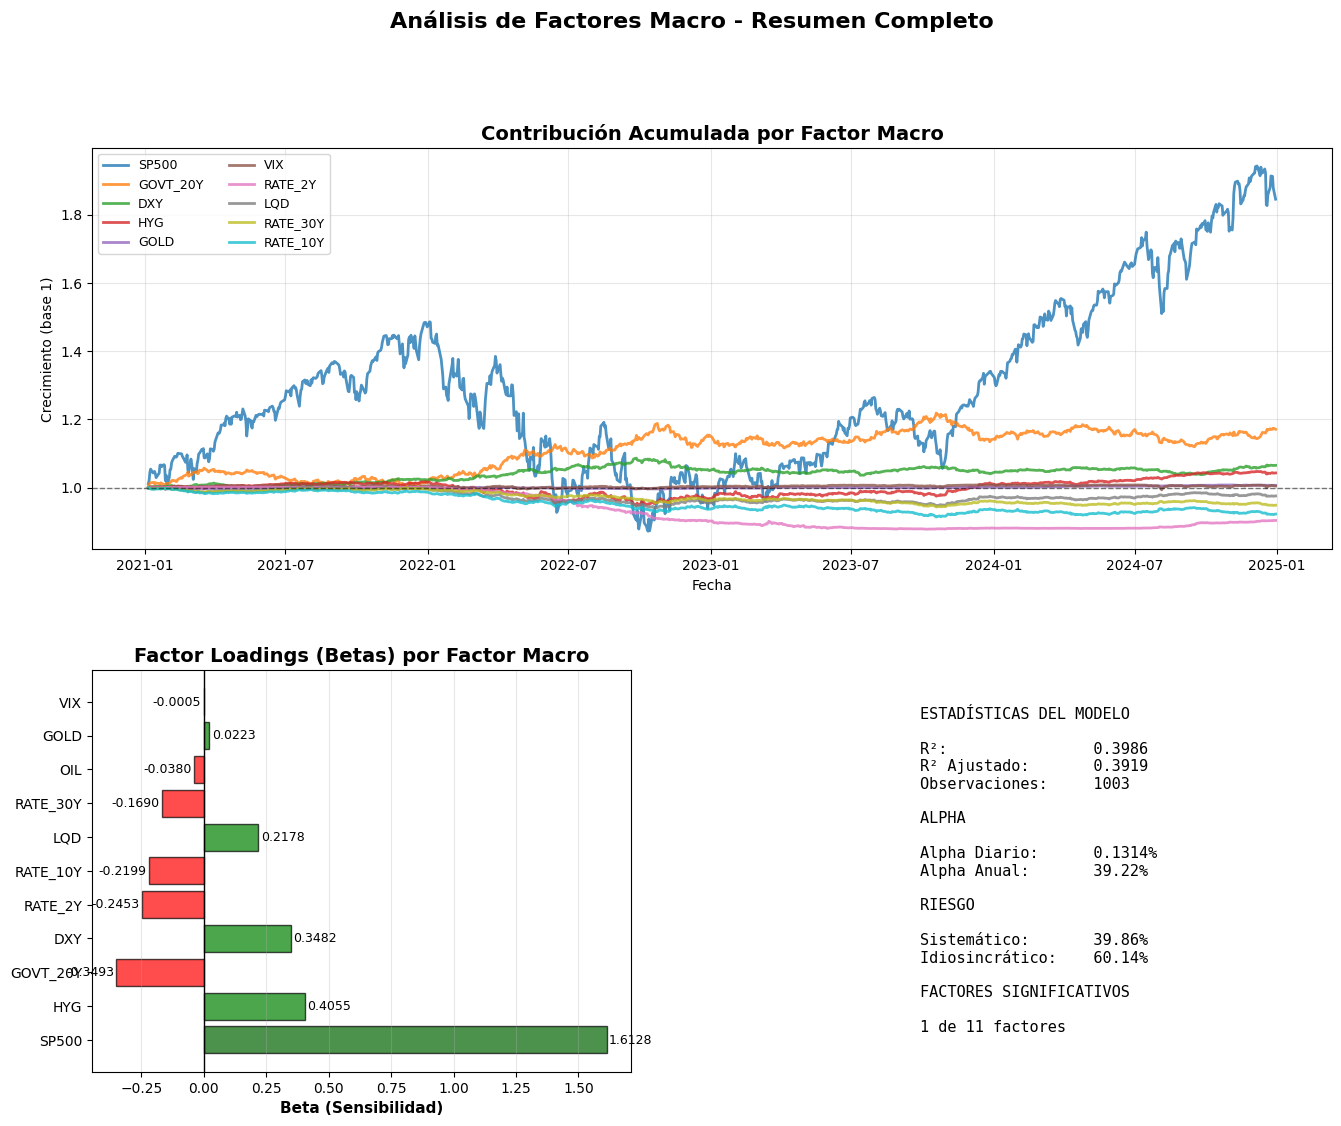


💡 Insight: Revisa el R² y los factores significativos


In [8]:
# ═══════════════════════════════════════════════════════════════════
# ANÁLISIS DE FACTORES MACRO
# ═══════════════════════════════════════════════════════════════════

print("📊 Ejecutando regresión multifactor...")
factor_results = factor_analyzer.analyze(
    portfolio_returns,
    pruned_factors,
    use_hac=True
)

# Reporte detallado
factor_reporter.print_analysis(factor_results)

# Visualización
fig = factor_viz.plot_factor_analysis(factor_results, top_n=10)
plt.show()

print("\n💡 Insight: Revisa el R² y los factores significativos")

🔗 Analizando correlaciones con lags...
                   ANÁLISIS DE CORRELACIONES MACRO                    
MEJORES CORRELACIONES (con lag óptimo)
Factor                   Corr    Lag     t-stat    p-value
SP500                   0.626      0     24.397     0.0000
HYG                     0.494      0     16.325     0.0000
VIX                    -0.469      0    -11.063     0.0000
credit_spread_hy_lqd    0.245      0      6.882     0.0000
LQD                     0.245      0      6.865     0.0000
credit_spread_hy        0.209      0      6.345     0.0000
DXY                    -0.194      0     -5.039     0.0000
RATE_10Y               -0.125    113     -3.877     0.0001
RATE_2Y                -0.121    -21     -3.153     0.0016
OIL                    -0.109     59     -3.252     0.0011

FACTORES LEADING (predicen portafolio)
  • RATE_2Y: -21 días adelantado (corr=-0.121)
FACTORES LAGGING (siguen al portafolio)
  • RATE_10Y: 113 días retrasado (corr=-0.125)
  • OIL: 59 días retrasado (

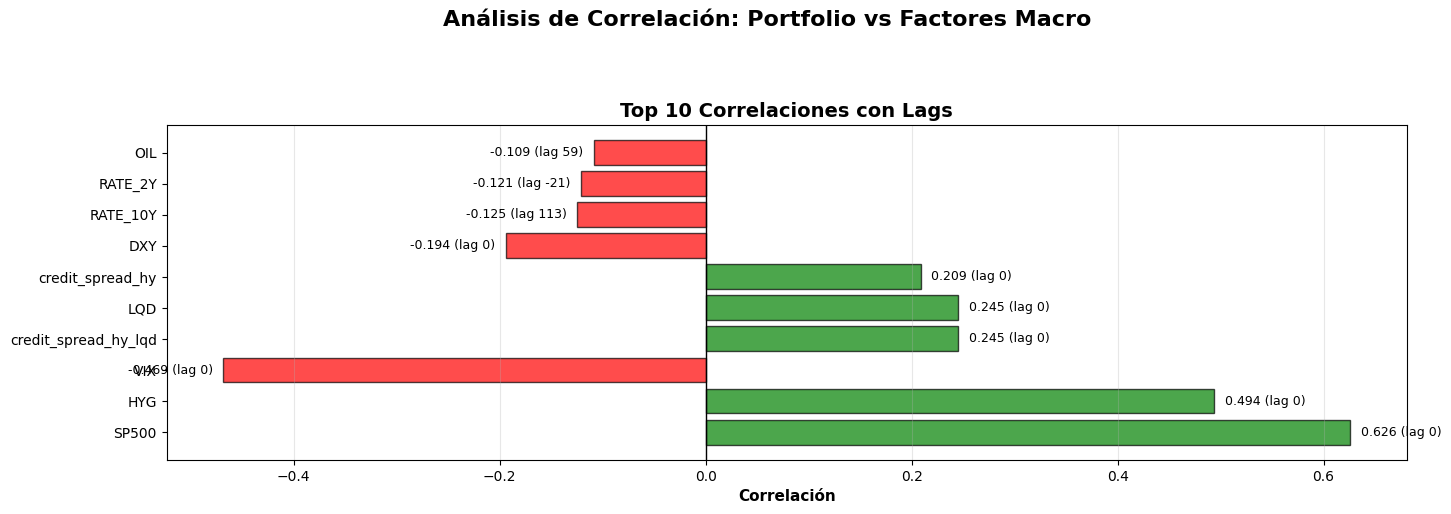


💡 Insight: Los factores leading predicen movimientos futuros del portfolio


In [9]:
# ═══════════════════════════════════════════════════════════════════
# ANÁLISIS DE CORRELACIONES LAGGED
# ═══════════════════════════════════════════════════════════════════

print("🔗 Analizando correlaciones con lags...")
corr_results = corr_analyzer.analyze(
    portfolio_returns,
    factors_for_analysis
)

# Reporte detallado
corr_reporter.print_analysis(corr_results)

# Visualización
fig = corr_viz.plot_correlation_analysis(corr_results, top_n=10)
plt.show()

print("\n💡 Insight: Los factores leading predicen movimientos futuros del portfolio")

📈 Analizando sensibilidades a factores macro...
                   ANÁLISIS DE SENSIBILIDADES MACRO                   
EXPOSICIONES POR MAGNITUD
ALTA EXPOSICIÓN (|β| > 0.5)
  ↑ SP500: β =   1.613
EXPOSICIÓN MODERADA (0.2 ≤ |β| ≤ 0.5)
  ↑ DXY: β =   0.348
  ↑ credit_spread_hy: β =   0.260
  ↓ RATE_2Y: β =  -0.245
  ↓ RATE_10Y: β =  -0.203
BAJA EXPOSICIÓN (|β| < 0.2)
    LQD: β =   0.194
    RATE_30Y: β =  -0.186
    HYG: β =   0.170
    GOVT_20Y: β =  -0.090
    OIL: β =  -0.038
FACTOR DOMINANTE
  SP500: β = 1.613
  Interpretación: Exposición muy alta

🔄 Calculando betas móviles...


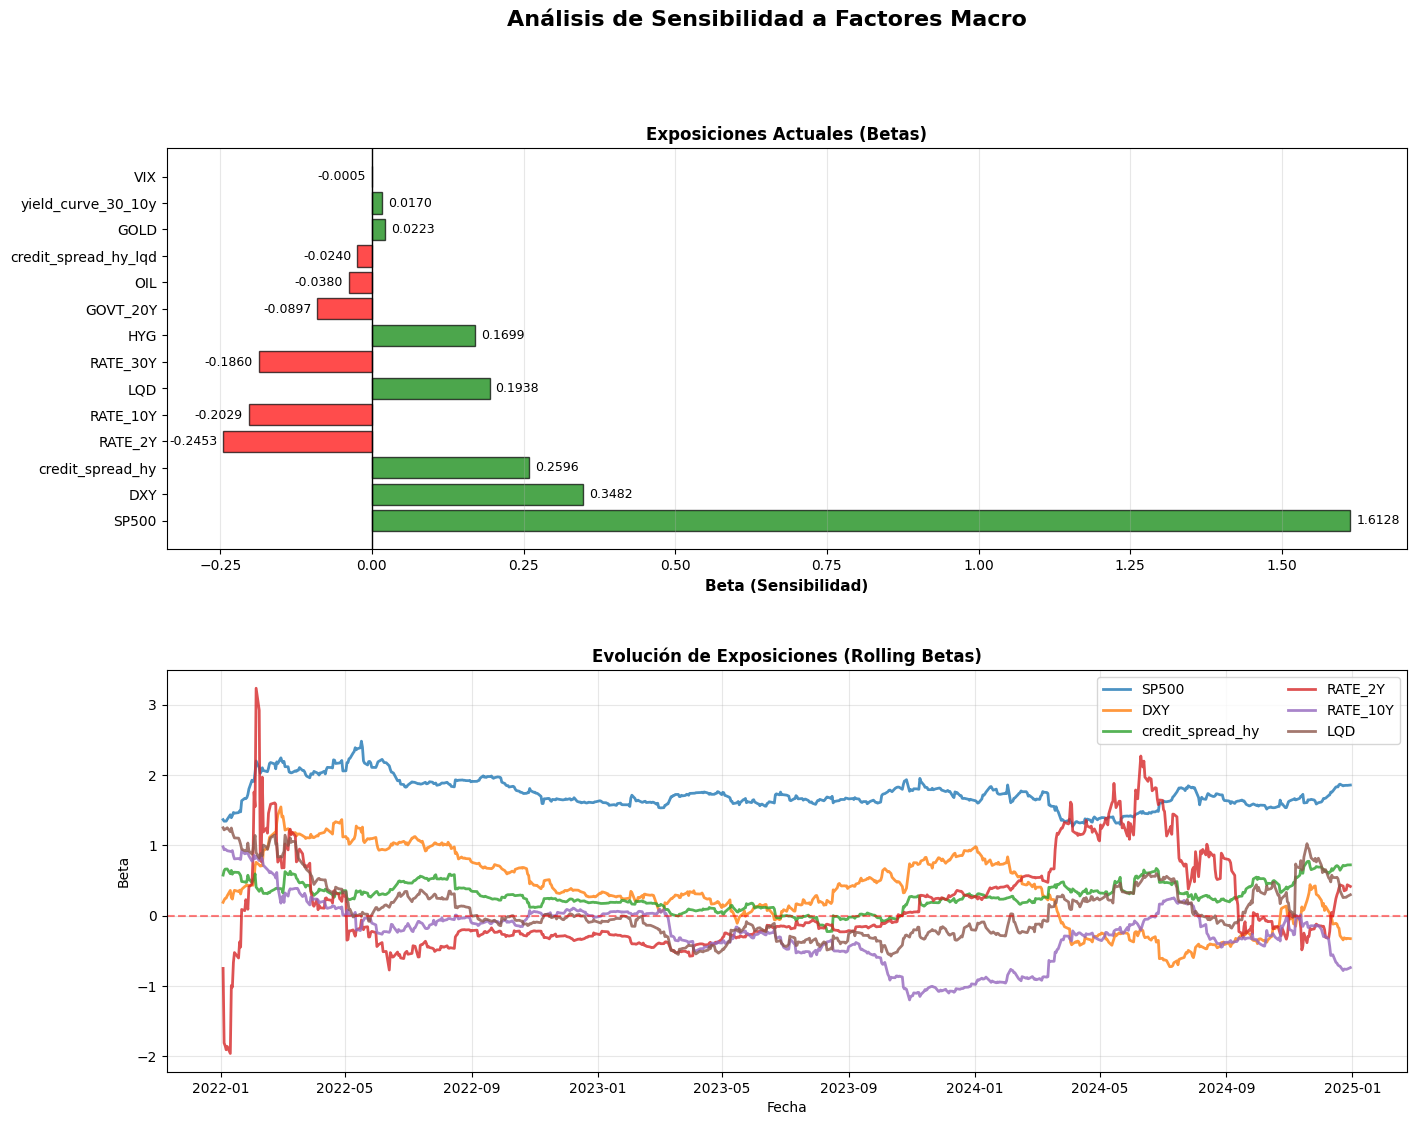


💡 Insight: Las sensibilidades pueden cambiar en el tiempo (ver betas móviles)


In [10]:
# ═══════════════════════════════════════════════════════════════════
# ANÁLISIS DE SENSIBILIDADES
# ═══════════════════════════════════════════════════════════════════

print("📈 Analizando sensibilidades a factores macro...")
sens_results = sens_analyzer.analyze(
    portfolio_returns,
    factors_for_analysis
)

# Reporte
sens_reporter.print_analysis(sens_results)

# Análisis rolling
print("\n🔄 Calculando betas móviles...")
rolling_betas = sens_analyzer.analyze_rolling(
    portfolio_returns,
    factors_for_analysis,
    window=REGIME_WINDOW
)

# Visualización combinada
fig = sens_viz.plot_sensitivity_analysis(
    sens_results, 
    rolling_betas=rolling_betas
)
plt.show()

print("\n💡 Insight: Las sensibilidades pueden cambiar en el tiempo (ver betas móviles)")

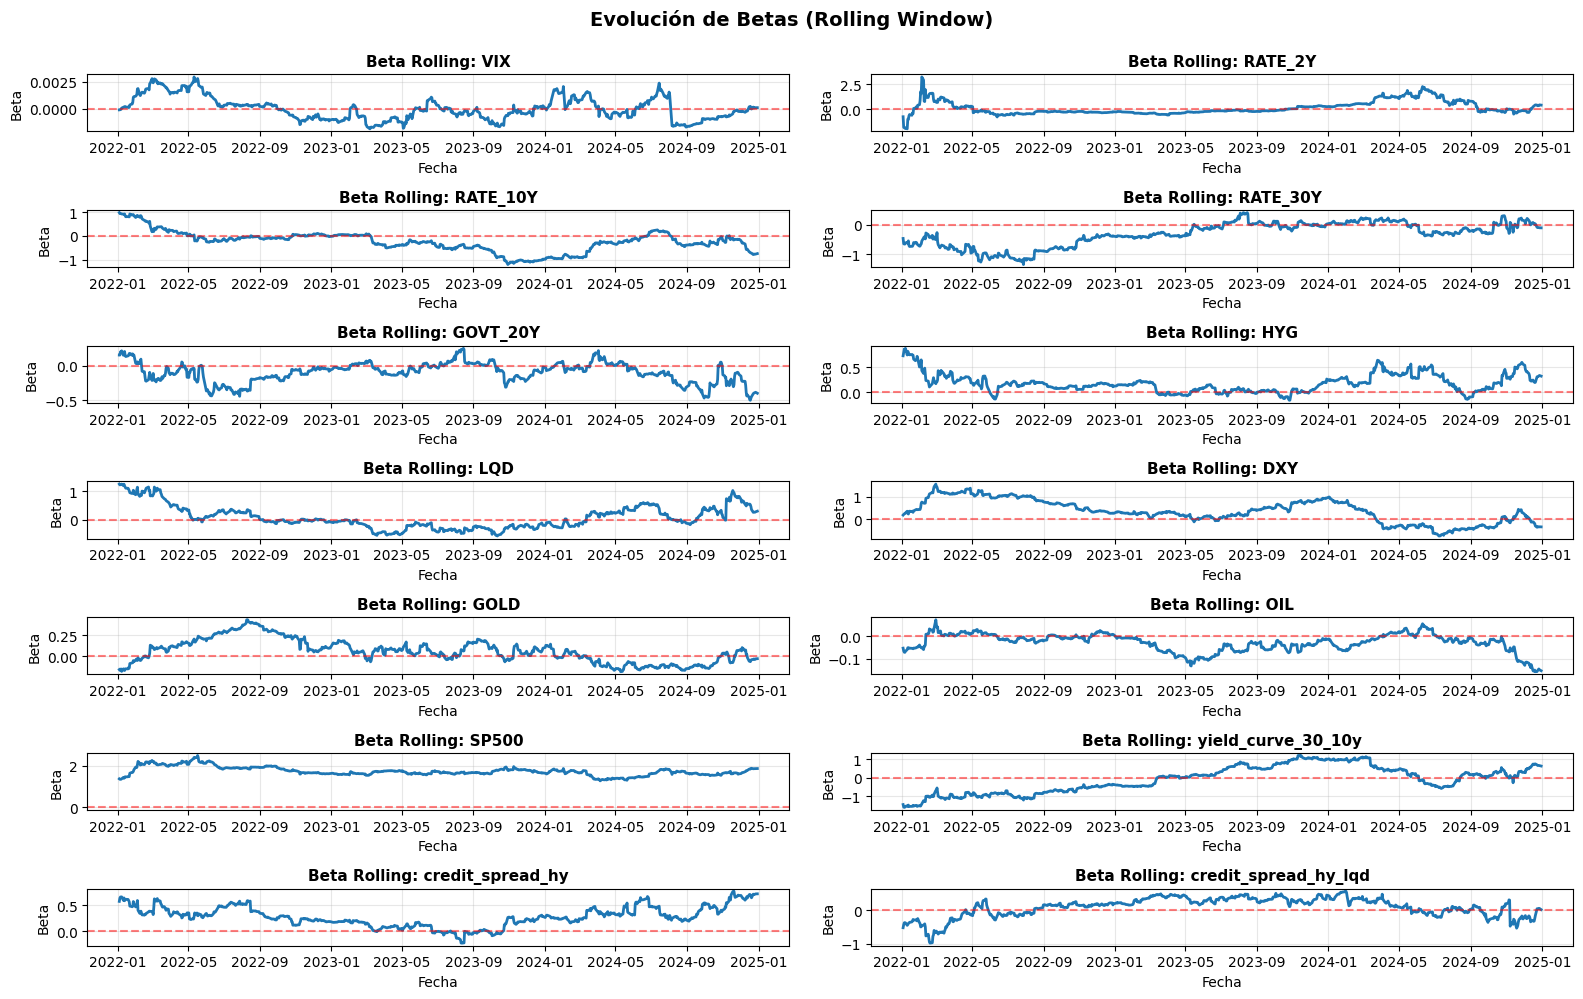

💡 Insight: Identifica cambios de régimen en las exposiciones


In [11]:
# ═══════════════════════════════════════════════════════════════════
# EVOLUCIÓN TEMPORAL DE SENSIBILIDADES
# ═══════════════════════════════════════════════════════════════════

fig = sens_viz.plot_rolling_betas(rolling_betas, figsize=(16, 10))
plt.show()

print("💡 Insight: Identifica cambios de régimen en las exposiciones")

🌍 Analizando situación macroeconómica global...
                        SITUACIÓN MACROECONÓMICA GLOBAL                         
RESUMEN EJECUTIVO

  Nivel de riesgo global: 🔴 ALTO

  Factores de riesgo detectados:
    • Expectativas inflacionarias elevadas
    • Inflación moderada-alta
    • Fuerte presión inflacionaria (metales)
    • Presión en bonos USA
    • Dólar debilitándose
CURVA DE TIPOS DE INTERÉS (USA)

  Niveles actuales:
     10Y:   4.55%
      2Y:   4.18%
     30Y:   4.76%
      5Y:   4.37%

  Spreads:
    🟢     10Y-2Y:  +0.36 pp
    🟢     10Y-5Y:  +0.18 pp
    🟢    30Y-10Y:  +0.22 pp

  Cambios en tasas:
    Tenor  1 Mes        3 Meses      1 Año       
    10Y     +0.37 pp     +0.80 pp     +0.68 pp   
    2Y      -0.19 pp     -0.30 pp     -1.00 pp   
    30Y     +0.40 pp     +0.68 pp     +0.74 pp   
    5Y      +0.32 pp     +0.85 pp     +0.53 pp   

  📊 Divergencia Corto vs Largo Plazo:
    3 meses:
      Corto (2Y):  -0.30 pp
      Largo (10Y):  +0.80 pp
      Diverge

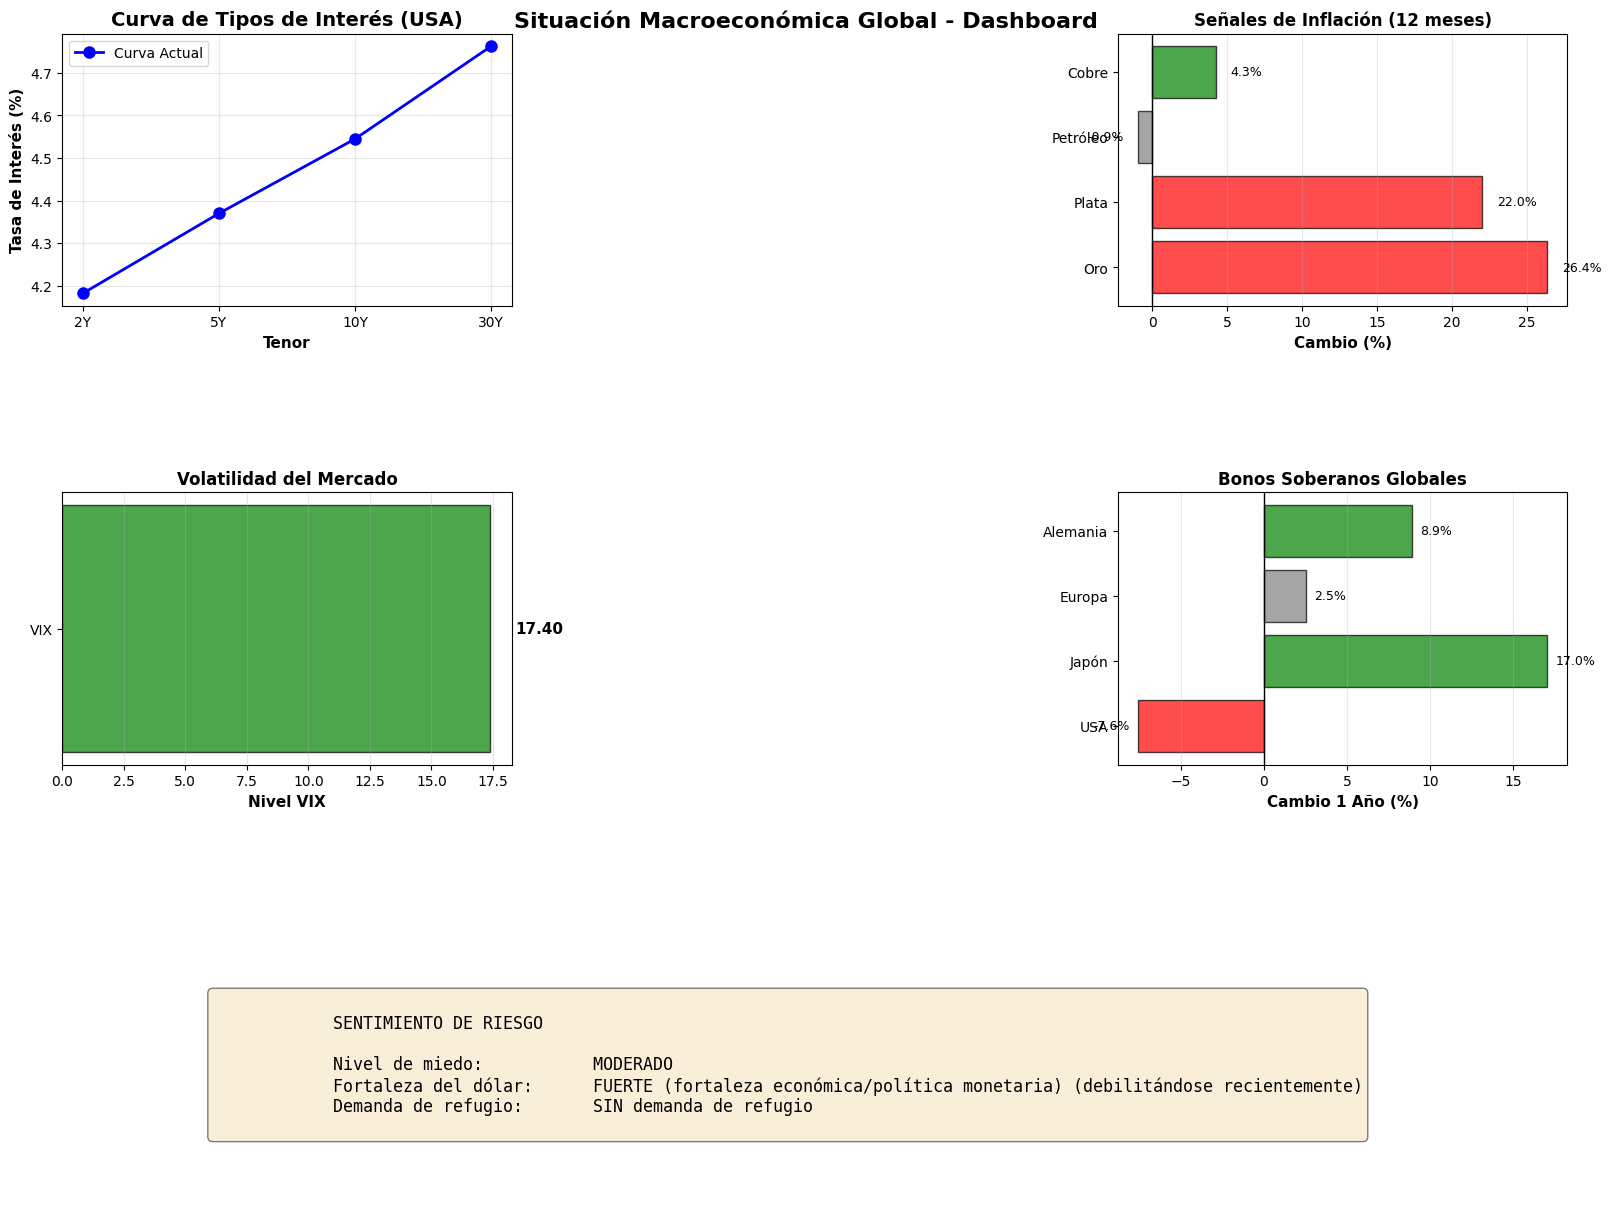


💡 Insight: Contexto macro actual para decisiones de inversión


In [12]:
# ═══════════════════════════════════════════════════════════════════
# ANÁLISIS DE SITUACIÓN MACROECONÓMICA
# ═══════════════════════════════════════════════════════════════════

print("🌍 Analizando situación macroeconómica global...")
situation_results = situation_analyzer.analyze(factors_raw)

# Reporte detallado
situation_reporter.print_situation(situation_results)

# Visualización (usa constrained_layout internamente, no necesita tight_layout)
fig = situation_viz.plot_macro_situation(situation_results)
plt.show()

print("\n💡 Insight: Contexto macro actual para decisiones de inversión")

In [13]:
# ═══════════════════════════════════════════════════════════════════
# ANÁLISIS DIRECTO CON COMPONENTES (Opcional - Más Control)
# ═══════════════════════════════════════════════════════════════════

# Si necesitas análisis personalizados, puedes usar los componentes directamente:

# Ejemplo 1: Correlación con lag específico para un factor
print("🔬 Análisis detallado: Correlación de SP500 con lags")
sp500_corr = correlation_calc.calculate_lagged(
    y=portfolio_returns,
    x=factors_for_analysis['SP500']
)
print(sp500_corr.nlargest(5, 'corr'))

# Ejemplo 2: Regresión con solo 2 factores
print("\n🔬 Análisis simplificado: Solo SP500 y VIX")
simple_factors = factors_for_analysis[['SP500', 'VIX']]
simple_regression = regression_calc.calculate_multifactor(
    portfolio_returns,
    simple_factors
)
print(f"R² del modelo simple: {simple_regression.r_squared:.3f}")
print(f"Beta SP500: {simple_regression.betas['SP500']:.3f}")
print(f"Beta VIX: {simple_regression.betas['VIX']:.3f}")

# Ejemplo 3: Descomposición de riesgo
print("\n🔬 Descomposición de riesgo:")
risk_decomp = regression_calc.calculate_risk_decomposition(
    simple_regression,
    simple_factors
)
print(f"Riesgo sistemático: {risk_decomp['systematic_pct']:.1f}%")
print(f"Riesgo idiosincrático: {risk_decomp['idiosyncratic_pct']:.1f}%")

print("\n💡 Los componentes te dan máxima flexibilidad para análisis custom")

🔬 Análisis detallado: Correlación de SP500 con lags
     lag      corr          t              p     n
126    0  0.626020  24.396628  1.857072e-131  1003
63   -63  0.115437   3.303229   9.557824e-04   940
135    9  0.100469   2.831872   4.627644e-03   994
25  -101  0.092468   2.638576   8.325512e-03   902
236  110  0.079649   2.310871   2.084001e-02   893

🔬 Análisis simplificado: Solo SP500 y VIX
R² del modelo simple: 0.392
Beta SP500: 1.745
Beta VIX: -0.001

🔬 Descomposición de riesgo:
Riesgo sistemático: 39.2%
Riesgo idiosincrático: 60.8%

💡 Los componentes te dan máxima flexibilidad para análisis custom
